# Causal steering with affective-subspace axes

**Hypothesis.** The continuous affective subspace found in
`affective_subspace_interpretation.ipynb` (PC1..PC4 plus the global intensity vector)
is not just a *descriptive* basis — adding `α · PC_k` to the residual stream at the
right layer should *causally* move generations in the expected direction on
continuous affective attributes (valence, threat, warmth, certainty, arousal, …),
and do so at least as cleanly as the named one-vs-rest emotion vectors.

**Steering layer.** 13 (matches `model.yaml` recommendation and the existing
`steering_experiment.ipynb`). Vectors are unit-normalized; α is in vector-norm units.

**What this notebook does.**

1. Reload activations and rebuild the PC basis from §1–§2 of the interpretation notebook.
2. Build a vector library: `PC1..PC4`, `v_intensity`, `v_emotion` (one-vs-rest, 8),
   plus a few `v_pairwise` (joy↔sadness, fear↔anger, trust↔disgust).
3. Generate `baseline / +α·vec / -α·vec` on neutral / weakly emotional prompts.
4. Sweep α over a grid and judge every generation with OpenAI (cached, resumable).
5. Plot monotonicity per (vector, attribute) — does the score move linearly with α?
6. Compare PC steering vs named-emotion steering: which is more controllable?

**Resume / dry-run controls.** API calls and generations are cached on disk.
Set `DRY_RUN_GEN = True` to skip model loading (uses a stub), and `DRY_RUN_JUDGE = True`
to fill judge scores with zeros. Both are off by default.

## 0. Setup

In [20]:
from __future__ import annotations

import gc
import hashlib
import json
import os
import time
import warnings
from contextlib import contextmanager, nullcontext
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from scipy import stats

warnings.filterwarnings('ignore', category=UserWarning)

REPO_ROOT = Path('../..').resolve()
ACT_DIR   = REPO_ROOT / 'activation' / 'emotion_rewrites'
NPY_PATH  = ACT_DIR / 'emotion_intensity_residual_stream.npy'
INFO_PATH = ACT_DIR / 'emotion_intensity_residual_stream_info.json'
OUT_DIR   = REPO_ROOT / 'analysis' / 'emotion_intensity' / 'subspace_steering'
OUT_DIR.mkdir(parents=True, exist_ok=True)
GEN_CACHE   = OUT_DIR / 'gen_cache'   ; GEN_CACHE.mkdir(exist_ok=True)
JUDGE_CACHE = OUT_DIR / 'judge_cache' ; JUDGE_CACHE.mkdir(exist_ok=True)

STEER_LAYER    = 13
K_PCS          = 4
MAX_SOURCES    = 2500
MAX_NEW_TOKENS = 40
SEED           = 0
ALPHA_GRID     = [-8, -5, -3, -1, 0, 1, 3, 5, 8]
ALPHA_DEFAULT  = 5.0

# Dry-run switches (off => real model + real OpenAI)
DRY_RUN_GEN   = False
DRY_RUN_JUDGE = False

JUDGE_MODEL    = 'gpt-4o-mini'
PROMPT_VERSION = 'v1'

rng = np.random.default_rng(SEED)
sns.set_context('notebook')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150})
print('OUT_DIR =', OUT_DIR)

OUT_DIR = /home/maplesugano/proj/EmotionEngine_v2/analysis/emotion_intensity/subspace_steering


## 1. Load activations and build the vector library

We rebuild the PC basis directly here (rather than depending on cached files) so the
notebook is self-contained. Procedure matches the interpretation notebook:

* Source-center per `(s, i)` so base-text semantics drop out.
* Centroid `C_e = mean_{s,i} R[s, e, i]`.
* SVD on `C - mean(C)` → top-K right singular vectors are PC1..PCK.

Comparison vectors:

* `v_intensity = mean_{s,e}(X[high] - X[low])` (computed on RAW activations).
* `v_emotion[e]` = one-vs-rest (matches the existing steering notebook).
* `v_pairwise[a, b]` for a handful of opponent pairs.

In [21]:
with open(INFO_PATH) as f:
    INFO = json.load(f)
LAYER_INDICES   = INFO['layer_indices']
EMOTION_ORDER   = INFO['emotion_order']
INTENSITY_ORDER = INFO['intensity_order']
SOURCE_IDS      = INFO['source_ids']
SHAPE           = tuple(INFO['shape'])
DTYPE           = INFO.get('dtype', 'float32')
N, N_EMO, N_INT, N_LAYERS, D = SHAPE
LI = LAYER_INDICES.index(STEER_LAYER)
INT_POS = {l: i for i, l in enumerate(INTENSITY_ORDER)}
EMO_POS = {e: i for i, e in enumerate(EMOTION_ORDER)}

ACT = np.memmap(str(NPY_PATH), dtype=DTYPE, mode='r', shape=SHAPE)
print('ACT shape =', ACT.shape, 'dtype =', DTYPE)
print('steer layer =', STEER_LAYER, '(li=', LI, ')')

ACT shape = (22782, 8, 3, 6, 4096) dtype = float32
steer layer = 13 (li= 2 )


In [22]:
if N > MAX_SOURCES:
    SRC_SUBSAMPLE = np.sort(rng.choice(N, size=MAX_SOURCES, replace=False))
else:
    SRC_SUBSAMPLE = np.arange(N)
N_SUB = len(SRC_SUBSAMPLE)

# ── Chunked accumulation: never materialise X or R in full ──────────────────
# Peak RAM per iteration: CHUNK_SIZE × N_EMO × N_INT × D × 8 bytes
# e.g. 128 × 8 × 3 × 4096 × 8 ≈ 100 MB — completely manageable.
CHUNK_SIZE = 128

# Accumulators (float64 for numerical stability)
emo_int_sum = np.zeros((N_EMO, N_INT, D), dtype=np.float64)   # Σ X[s,e,i]
int_hi_sum  = np.zeros(D, dtype=np.float64)                    # Σ_{s,e} X[s,e,high]
int_lo_sum  = np.zeros(D, dtype=np.float64)                    # Σ_{s,e} X[s,e,low]
n_acc = 0

for start in range(0, N_SUB, CHUNK_SIZE):
    end   = min(start + CHUNK_SIZE, N_SUB)
    chunk = np.asarray(ACT[SRC_SUBSAMPLE[start:end], :, :, LI, :],
                       dtype=np.float64)           # (k, N_EMO, N_INT, D)
    emo_int_sum += chunk.sum(axis=0)              # (N_EMO, N_INT, D)
    int_hi_sum  += chunk[:, :, INT_POS['high'], :].sum(axis=(0, 1))
    int_lo_sum  += chunk[:, :, INT_POS['low'],  :].sum(axis=(0, 1))
    n_acc += end - start
    del chunk
    gc.collect()

print(f'Accumulated {n_acc} sources in chunks of {CHUNK_SIZE}.')

# ── Derived means ────────────────────────────────────────────────────────────
# emo_int_mean[e, i] = mean_s X[s, e, i]
emo_int_mean  = (emo_int_sum / n_acc).astype(np.float32)        # (N_EMO, N_INT, D)

# emo_mean_all[e]   = mean_{s,i} X[s, e, i]
emo_mean_all  = emo_int_mean.mean(axis=1)                       # (N_EMO, D)

# grand_mean_vec    = mean_{s,e,i} X[s, e, i]
grand_mean_vec = emo_mean_all.mean(axis=0)                      # (D,)

# Source-centered emotion centroid:
#   C[e] = mean_{s,i} R[s,e,i]
#         = mean_{s,i} X[s,e,i] - mean_{s,i,e'} X[s,e',i]
#         = emo_mean_all[e]     - grand_mean_vec
C = emo_mean_all - grand_mean_vec                               # (N_EMO, D)

# ── SVD ──────────────────────────────────────────────────────────────────────
C_mean = C.mean(axis=0, keepdims=True)
U, S, Vt = np.linalg.svd((C - C_mean).astype(np.float64), full_matrices=False)
PC  = Vt[:K_PCS].astype(np.float32)                            # (K_PCS, D)
evr = (S ** 2) / (S ** 2).sum()
print('singular values:', np.round(S, 3))
print('EVR            :', np.round(evr, 3))
print('cum EVR        :', np.round(np.cumsum(evr), 3))

score_df = pd.DataFrame(
    ((C - C_mean) @ PC.T), index=EMOTION_ORDER,
    columns=[f'PC{i+1}' for i in range(K_PCS)],
).round(3)
score_df


Accumulated 2500 sources in chunks of 128.
singular values: [1.999 1.517 1.153 0.893 0.745 0.571 0.372 0.   ]
EVR            : [0.423 0.244 0.141 0.084 0.059 0.035 0.015 0.   ]
cum EVR        : [0.423 0.667 0.808 0.892 0.951 0.985 1.    1.   ]


,PC1,PC2,PC3,PC4
joy,-0.943,0.340,-0.323,-0.473
trust,-1.003,-0.249,-0.371,0.565
fear,0.359,-0.653,0.558,0.186
surprise,0.167,1.228,0.432,0.236
sadness,0.469,-0.145,0.088,-0.337
disgust,0.761,-0.073,-0.428,0.051
anger,0.846,-0.047,-0.423,-0.010
anticipation,-0.657,-0.401,0.468,-0.217


In [23]:
def unit(v: np.ndarray) -> np.ndarray:
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return v / (n + 1e-10)

# Global intensity vector — from accumulated sums (no full X needed).
# int_hi_sum / (n_acc * N_EMO) = mean_{s,e} X[s,e,high]
v_intensity = unit(
    (int_hi_sum / (n_acc * N_EMO) - int_lo_sum / (n_acc * N_EMO)).astype(np.float32)
)

# One-vs-rest emotion vectors — from emo_mean_all (mirrors steering_experiment.ipynb).
v_emotion = unit(
    emo_mean_all - (emo_mean_all.sum(axis=0, keepdims=True) - emo_mean_all) / (N_EMO - 1)
)

# Opponent-pair vectors — from C (source-centered centroid), no full R needed.
PAIRS = [('joy', 'sadness'), ('sadness', 'joy'), ('fear', 'anger'), ('anger', 'fear'),
         ('trust', 'disgust'), ('disgust', 'trust')]
v_pairwise = {}
for a, b in PAIRS:
    v_pairwise[(a, b)] = unit(C[EMO_POS[a]] - C[EMO_POS[b]])

# Free accumulator arrays — all vectors are now materialized.
del emo_int_sum, emo_int_mean, int_hi_sum, int_lo_sum, emo_mean_all, C
gc.collect()

# Pack the vector library.
VECTORS: dict[str, np.ndarray] = {}
for k in range(K_PCS):
    VECTORS[f'PC{k+1}'] = unit(PC[k])
VECTORS['v_intensity'] = v_intensity
for e in EMOTION_ORDER:
    VECTORS[f'v_{e}'] = v_emotion[EMO_POS[e]]
for (a, b), v in v_pairwise.items():
    VECTORS[f'v_{a}_minus_{b}'] = v

# Save the vector library so other notebooks can reuse.
np.savez(
    OUT_DIR / 'steering_vectors.npz',
    **{k: v.astype(np.float32) for k, v in VECTORS.items()},
)
print('vectors:', list(VECTORS.keys()))
print('saved   :', OUT_DIR / 'steering_vectors.npz')

vectors: ['PC1', 'PC2', 'PC3', 'PC4', 'v_intensity', 'v_joy', 'v_trust', 'v_fear', 'v_surprise', 'v_sadness', 'v_disgust', 'v_anger', 'v_anticipation', 'v_joy_minus_sadness', 'v_sadness_minus_joy', 'v_fear_minus_anger', 'v_anger_minus_fear', 'v_trust_minus_disgust', 'v_disgust_minus_trust']
saved   : /home/maplesugano/proj/EmotionEngine_v2/analysis/emotion_intensity/subspace_steering/steering_vectors.npz


## 2. Expected effect direction per (axis, attribute)

For each axis we record the *predicted* sign of each attribute's change when we add `+α · axis`.
Predictions for PCs come from the per-emotion PC table (which emotions sit on each side)
and the qualitative reading of PC1≈valence, PC2≈novelty/surprise.

If the previous notebook's `pc_vs_judge_corr.csv` exists, we *override* the manual guesses
with `sign(spearman ρ)` — that gives us an empirical prediction to test causally.

In [24]:
JUDGE_ATTRS = ['valence', 'arousal', 'dominance', 'emotional_intensity',
               'threat', 'social_warmth', 'certainty', 'agency']

# Manual fallback predictions, derived from the per-emotion PC table.
# Convention: predicted *sign* of attribute change when adding +α·axis.
MANUAL_PRED = {
    'PC1': {'valence': -1, 'social_warmth': -1, 'threat': +1, 'dominance': -1,
            'certainty': -1, 'agency': 0, 'arousal': 0, 'emotional_intensity': 0},
    'PC2': {'arousal': +1, 'emotional_intensity': +1, 'certainty': -1,
            'valence': 0, 'social_warmth': 0, 'threat': 0, 'dominance': 0, 'agency': 0},
    'PC3': {'threat': +1, 'certainty': -1, 'agency': 0, 'valence': 0,
            'arousal': 0, 'dominance': 0, 'social_warmth': 0, 'emotional_intensity': 0},
    'PC4': {'social_warmth': +1, 'certainty': +1, 'valence': +1, 'threat': -1,
            'dominance': 0, 'agency': 0, 'arousal': 0, 'emotional_intensity': 0},
    'v_intensity': {'arousal': +1, 'emotional_intensity': +1, 'valence': 0,
                    'social_warmth': 0, 'threat': 0, 'dominance': 0,
                    'certainty': 0, 'agency': 0},
}

# Try to load the empirical correlation table and use its signs.
PRIOR_CORR_PATH = REPO_ROOT / 'analysis' / 'emotion_intensity' / 'affective_subspace' / 'pc_vs_judge_corr.csv'
PREDICTED_SIGN: dict[str, dict[str, int]] = {k: dict(v) for k, v in MANUAL_PRED.items()}
if PRIOR_CORR_PATH.exists():
    prior = pd.read_csv(PRIOR_CORR_PATH, index_col=0)
    for axis in [f'PC{i+1}' for i in range(K_PCS)]:
        if axis in prior.index:
            for a in JUDGE_ATTRS:
                if a in prior.columns and not pd.isna(prior.loc[axis, a]):
                    PREDICTED_SIGN[axis][a] = int(np.sign(prior.loc[axis, a]))
    print('Loaded empirical predictions from', PRIOR_CORR_PATH.name)
else:
    print('No prior correlation file — using MANUAL_PRED only.')

pd.DataFrame(PREDICTED_SIGN).T.loc[['PC1','PC2','PC3','PC4','v_intensity']]

Loaded empirical predictions from pc_vs_judge_corr.csv


,valence,social_warmth,threat,dominance,certainty,agency,arousal,emotional_intensity
PC1,-1,-1,1,-1,-1,-1,1,1
PC2,1,1,-1,1,1,1,1,1
PC3,1,1,1,-1,-1,-1,1,-1
PC4,-1,-1,1,-1,-1,-1,-1,-1
v_intensity,0,0,0,0,0,0,1,1


## 3. Load the model (or stub)

`DRY_RUN_GEN = True` skips loading and uses a stub `generate_steered` that just echoes the
axis/alpha, so the rest of the pipeline (caching, judge, plotting) can be validated
without a GPU.

In [25]:
model = None
tokenizer = None
model_dtype = None
model_device = None

if not DRY_RUN_GEN:
    import psutil
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

    with open(REPO_ROOT / 'model.yaml') as f:
        cfg = yaml.safe_load(f)
    MODEL_NAME = cfg['name']
    DTYPE_MAP  = {'bfloat16': torch.bfloat16, 'float16': torch.float16, 'float32': torch.float32}
    MODEL_DTYPE = DTYPE_MAP.get(cfg.get('dtype', 'bfloat16'), torch.bfloat16)
    ATTN_IMPL   = cfg.get('attn_implementation', 'sdpa')
    USE_4BIT    = cfg.get('load_in_4bit', False)

    print(f'Available RAM: {psutil.virtual_memory().available/1e9:.1f} GB | loading {MODEL_NAME} …')
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    tokenizer.padding_side = 'left'
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    bnb_cfg = None
    if USE_4BIT:
        bnb_cfg = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16,
                                     bnb_4bit_use_double_quant=True, bnb_4bit_quant_type='nf4')
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, torch_dtype=MODEL_DTYPE, attn_implementation=ATTN_IMPL,
        device_map='auto', low_cpu_mem_usage=True, quantization_config=bnb_cfg,
    )
    model.eval()
    model_dtype  = next(model.parameters()).dtype
    model_device = next(model.parameters()).device
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    print(f'Model loaded. d_model={model.config.hidden_size}  n_layers={model.config.num_hidden_layers}')
    print(f'Steering target: model.model.layers[{STEER_LAYER}]')
else:
    print('DRY_RUN_GEN=True — no model loaded; using stub.')

Available RAM: 22.2 GB | loading meta-llama/Llama-3.1-8B-Instruct …


Loading weights: 100%|██████████| 291/291 [00:22<00:00, 12.81it/s]


Model loaded. d_model=4096  n_layers=32
Steering target: model.model.layers[13]


## 4. Steering hook + cached generation

In [26]:
def make_prompt(user_text: str) -> str:
    """Llama-3.1-Instruct chat template wrapping a single user turn."""
    if tokenizer is None:
        return user_text
    msgs = [
        {'role': 'system', 'content': 'Rewrite the sentence in one sentence so it aligns with user''s feelings more.'},
        {'role': 'user',   'content': user_text},
    ]
    return tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)

if not DRY_RUN_GEN:
    import torch
    @contextmanager
    def steer_at_layer(layer_idx: int, vec: np.ndarray, alpha: float):
        vec_t = torch.from_numpy(np.ascontiguousarray(vec)).to(
            dtype=model_dtype, device=model_device
        )
        vec_t = vec_t / (vec_t.norm() + 1e-10)
        vec_t = vec_t.reshape(1, 1, -1)
        def _hook(module, inp, out):
            hidden = out[0] if isinstance(out, tuple) else out
            rest   = out[1:] if isinstance(out, tuple) else None
            hidden = hidden.clone()
            hidden[:, -1:, :] = hidden[:, -1:, :] + alpha * vec_t
            return (hidden, *rest) if rest is not None else hidden
        h = model.model.layers[layer_idx].register_forward_hook(_hook)
        try:
            yield
        finally:
            h.remove()

    def _generate_raw(prompt: str, vec: np.ndarray | None, alpha: float) -> str:
        enc = tokenizer(prompt, return_tensors='pt').to(model_device)
        with torch.inference_mode():
            cm = steer_at_layer(STEER_LAYER, vec, alpha) if (vec is not None and alpha != 0) else nullcontext()
            with cm:
                out_ids = model.generate(
                    **enc, max_new_tokens=MAX_NEW_TOKENS, do_sample=False,
                    pad_token_id=tokenizer.pad_token_id,
                )
        new_ids = out_ids[0, enc['input_ids'].shape[1]:]
        return tokenizer.decode(new_ids, skip_special_tokens=True).strip()
else:
    def _generate_raw(prompt: str, vec: np.ndarray | None, alpha: float) -> str:
        return f'[stub gen | alpha={alpha:+.1f} | prompt_head={prompt[:30]!r}]'

GEN_PROMPT_VERSION = 'v1'
def _gen_key(prompt: str, axis_name: str, alpha: float) -> str:
    h = hashlib.sha1()
    h.update(GEN_PROMPT_VERSION.encode()); h.update(b'|')
    h.update(str(STEER_LAYER).encode()); h.update(b'|')
    h.update(axis_name.encode()); h.update(b'|')
    h.update(f'{alpha:+.4f}'.encode()); h.update(b'|')
    h.update(prompt.encode('utf-8'))
    return h.hexdigest()[:24]

def generate_cached(base_text: str, axis_name: str, vec: np.ndarray | None, alpha: float) -> str:
    prompt = make_prompt(base_text)
    key = _gen_key(prompt, axis_name, alpha)
    path = GEN_CACHE / f'{key}.json'
    if path.exists():
        return json.loads(path.read_text())['output']
    out = _generate_raw(prompt, vec, alpha)
    path.write_text(json.dumps({'base': base_text, 'axis': axis_name, 'alpha': alpha, 'output': out}))
    return out

print('generation pipeline ready. DRY_RUN_GEN =', DRY_RUN_GEN)

generation pipeline ready. DRY_RUN_GEN = False


## 5. Prompts

Mix of *neutral* and *weakly emotional* one-liners — small enough that a sweep is
tractable, varied enough that no single prompt dominates.

In [27]:
PROMPTS = [
    'I guess that was okay.',
    'The meeting went alright.',
    "I'm not sure how to feel about this.",
    'Tell me about your day.',
    'I just got the news.',
    'The weather is changing again.',
    'We need to talk about the project.',
    "It's been a long week.",
]
print(f'{len(PROMPTS)} prompts')

8 prompts


## 6. Qualitative table at α = ±ALPHA_DEFAULT

Eyeball check before the full sweep. Each row: `(prompt, axis, alpha)` → generation.

In [28]:
QUAL_AXES = ['PC1', 'PC2', 'PC3', 'PC4', 'v_intensity', 'v_joy', 'v_sadness', 'v_fear']
QUAL_ALPHAS = [-ALPHA_DEFAULT, +ALPHA_DEFAULT]

qual_rows = []
for base in PROMPTS:
    baseline = generate_cached(base, 'baseline', None, 0.0)
    qual_rows.append({'prompt': base, 'axis': 'baseline', 'alpha': 0.0, 'output': baseline})
    for axis_name in QUAL_AXES:
        for a in QUAL_ALPHAS:
            out = generate_cached(base, axis_name, VECTORS[axis_name], a)
            qual_rows.append({'prompt': base, 'axis': axis_name, 'alpha': a, 'output': out})
QUAL_DF = pd.DataFrame(qual_rows)
QUAL_DF.to_csv(OUT_DIR / 'qualitative_generations.csv', index=False)
print('rows:', len(QUAL_DF))

# Pretty-print first 2 prompts.
for base in PROMPTS[:2]:
    print(f"\n{'='*70}\nPrompt: {base}\n{'='*70}")
    sub = QUAL_DF[QUAL_DF['prompt'] == base]
    for _, r in sub.iterrows():
        tag = f"[{r['axis']:>14}|α={r['alpha']:+.1f}]"
        print(f"  {tag}  {r['output']}")

rows: 136

Prompt: I guess that was okay.
  [      baseline|α=+0.0]  It was a decent experience.
  [           PC1|α=-5.0]  It was a decent experience.
  [           PC1|α=+5.0]  I was expecting a more enthusiastic response, but I guess that was just "meh" - it was just okay.
  [           PC2|α=-5.0]  The experience was somewhat satisfactory.
  [           PC2|α=+5.0]  That was a decent experience, I'd say it was pretty good.
  [           PC3|α=-5.0]  It was a decent experience.
  [           PC3|α=+5.0]  It was a decent experience, and I'm glad it turned out as well as it did.
  [           PC4|α=-5.0]  The experience was just average, and it didn't quite live up to my expectations.
  [           PC4|α=+5.0]  It was fine, I suppose.
  [   v_intensity|α=-5.0]  It was somewhat satisfactory.
  [   v_intensity|α=+5.0]  You're left feeling a bit underwhelmed and wondering if it could have been more impactful.
  [         v_joy|α=-5.0]  The experience was somewhat underwhelming.
  [      

## 7. α sweep: generations for the full grid

Generate `(prompt × axis × alpha)` cells for the sweep set. Cached, so repeating with
a wider grid is cheap.

In [29]:
SWEEP_AXES = ['PC1', 'PC2', 'PC3', 'PC4', 'v_intensity',
              'v_joy', 'v_sadness', 'v_fear', 'v_anger', 'v_trust',
              'v_joy_minus_sadness', 'v_fear_minus_anger']
SWEEP_AXES = [a for a in SWEEP_AXES if a in VECTORS]

sweep_rows = []
t0 = time.time()
n_total = len(PROMPTS) * (1 + len(SWEEP_AXES) * len(ALPHA_GRID))
done = 0
for base in PROMPTS:
    base_out = generate_cached(base, 'baseline', None, 0.0)
    sweep_rows.append({'prompt': base, 'axis': 'baseline', 'alpha': 0.0, 'output': base_out})
    done += 1
    for axis_name in SWEEP_AXES:
        vec = VECTORS[axis_name]
        for a in ALPHA_GRID:
            out = generate_cached(base, axis_name, vec, a)
            sweep_rows.append({'prompt': base, 'axis': axis_name, 'alpha': float(a), 'output': out})
            done += 1
    if not DRY_RUN_GEN:
        print(f'  prompt done: {base!r:50s}  cum {done}/{n_total}  ({time.time()-t0:.0f}s)')
SWEEP_DF = pd.DataFrame(sweep_rows).drop_duplicates(subset=['prompt', 'axis', 'alpha'])
SWEEP_DF.to_parquet(OUT_DIR / 'sweep_generations.parquet')
print('sweep rows:', len(SWEEP_DF))

  prompt done: 'I guess that was okay.'                            cum 109/872  (30s)
  prompt done: 'The meeting went alright.'                         cum 218/872  (65s)
  prompt done: "I'm not sure how to feel about this."              cum 327/872  (109s)
  prompt done: 'Tell me about your day.'                           cum 436/872  (205s)
  prompt done: 'I just got the news.'                              cum 545/872  (237s)
  prompt done: 'The weather is changing again.'                    cum 654/872  (289s)
  prompt done: 'We need to talk about the project.'                cum 763/872  (341s)
  prompt done: "It's been a long week."                            cum 872/872  (385s)
sweep rows: 872


## 8. OpenAI judge (cached, resumable)

Same prompt and schema as the interpretation notebook so scores are comparable.
Cache is *separate* from the interpretation cache — generations and rewrites are
different text distributions.

In [30]:
ATTR_RANGES = {
    'valence':             (-1.0, 1.0),
    'arousal':             (0.0, 1.0),
    'dominance':           (-1.0, 1.0),
    'emotional_intensity': (0.0, 1.0),
    'threat':              (0.0, 1.0),
    'social_warmth':       (-1.0, 1.0),
    'certainty':           (-1.0, 1.0),
    'agency':              (-1.0, 1.0),
}

JUDGE_SYSTEM = (
    'You are an expert affective-computing annotator. Given one short piece of text, '
    'rate the *affective state of the speaker as expressed by the text*, not your '
    'opinion of the text. Output strict JSON conforming to the schema. Use the full '
    'range and be decisive; do not default to zero.'
)
JUDGE_USER_TMPL = (
    'Rate the speaker on these continuous affective attributes. Each is a single number.\n\n'
    'Scales:\n'
    '- valence             in [-1, 1]   negative <-> positive feeling\n'
    '- arousal             in [ 0, 1]   calm    <-> highly aroused / energized / tense\n'
    '- dominance           in [-1, 1]   powerless / submissive <-> in-control / dominant\n'
    '- emotional_intensity in [ 0, 1]   flat <-> intense emotion of any kind\n'
    '- threat              in [ 0, 1]   safe <-> perceiving danger or threat\n'
    '- social_warmth       in [-1, 1]   cold/hostile <-> warm/affiliative\n'
    '- certainty           in [-1, 1]   confused/uncertain <-> confident/certain\n'
    '- agency              in [-1, 1]   passive/acted-upon <-> active/initiating\n\n'
    'TEXT:\n"""\n{text}\n"""\n'
)
JUDGE_SCHEMA = {
    'name': 'affect_scores', 'strict': True,
    'schema': {
        'type': 'object', 'additionalProperties': False,
        'properties': {k: {'type': 'number'} for k in JUDGE_ATTRS},
        'required': JUDGE_ATTRS,
    },
}

def _jkey(text: str) -> str:
    h = hashlib.sha1()
    h.update(JUDGE_MODEL.encode()); h.update(b'|')
    h.update(PROMPT_VERSION.encode()); h.update(b'|')
    h.update(text.encode('utf-8'))
    return h.hexdigest()[:24]

def _clip(d: dict) -> dict:
    return {k: float(np.clip(float(d.get(k, 0.0)), lo, hi))
            for k, (lo, hi) in ATTR_RANGES.items()}

_client = None
def _get_client():
    global _client
    if _client is None:
        from openai import OpenAI
        if not os.environ.get('OPENAI_API_KEY'):
            raise RuntimeError('OPENAI_API_KEY is not set. Export it or set DRY_RUN_JUDGE=True.')
        _client = OpenAI()
    return _client

def judge_one(text: str) -> dict:
    p = JUDGE_CACHE / f'{_jkey(text)}.json'
    if p.exists():
        return json.loads(p.read_text())
    if DRY_RUN_JUDGE:
        scores = {k: 0.0 for k in JUDGE_ATTRS}
        p.write_text(json.dumps(scores))
        return scores
    resp = _get_client().chat.completions.create(
        model=JUDGE_MODEL, temperature=0.0,
        messages=[{'role': 'system', 'content': JUDGE_SYSTEM},
                  {'role': 'user',   'content': JUDGE_USER_TMPL.format(text=text)}],
        response_format={'type': 'json_schema', 'json_schema': JUDGE_SCHEMA},
    )
    scores = _clip(json.loads(resp.choices[0].message.content))
    p.write_text(json.dumps(scores))
    return scores

def judge_many(texts: list[str], every: int = 25) -> list[dict]:
    out = []
    t0 = time.time()
    for i, t in enumerate(texts):
        out.append(judge_one(t))
        if (i + 1) % every == 0 or i == len(texts) - 1:
            print(f'  judged {i+1}/{len(texts)}  ({time.time()-t0:.1f}s)')
    return out

In [31]:
ALL_GENS = pd.concat([QUAL_DF, SWEEP_DF], ignore_index=True).drop_duplicates(
    subset=['prompt', 'axis', 'alpha']
)
print('unique generations to judge:', len(ALL_GENS))
judged = judge_many(ALL_GENS['output'].tolist())
JUDGE_DF = pd.concat([ALL_GENS.reset_index(drop=True), pd.DataFrame(judged)], axis=1)
JUDGE_DF.to_parquet(OUT_DIR / 'judge_scores.parquet')
JUDGE_DF.head()

unique generations to judge: 872
  judged 25/872  (30.1s)
  judged 50/872  (64.1s)
  judged 75/872  (102.3s)
  judged 100/872  (134.3s)
  judged 125/872  (172.1s)
  judged 150/872  (195.9s)
  judged 175/872  (205.3s)
  judged 200/872  (222.2s)
  judged 225/872  (235.5s)
  judged 250/872  (254.0s)
  judged 275/872  (270.4s)
  judged 300/872  (284.9s)
  judged 325/872  (305.2s)
  judged 350/872  (324.6s)
  judged 375/872  (336.2s)
  judged 400/872  (350.5s)
  judged 425/872  (375.5s)
  judged 450/872  (399.8s)
  judged 475/872  (418.2s)
  judged 500/872  (445.1s)
  judged 525/872  (463.1s)
  judged 550/872  (473.9s)
  judged 575/872  (485.2s)
  judged 600/872  (501.1s)
  judged 625/872  (526.5s)
  judged 650/872  (548.2s)
  judged 675/872  (576.4s)
  judged 700/872  (591.0s)
  judged 725/872  (605.5s)
  judged 750/872  (613.7s)
  judged 775/872  (626.1s)
  judged 800/872  (644.6s)
  judged 825/872  (667.0s)
  judged 850/872  (680.6s)
  judged 872/872  (692.5s)


,prompt,axis,alpha,output,valence,arousal,dominance,emotional_intensity,threat,social_warmth,certainty,agency
0,I guess that was okay.,baseline,0.0,It was a decent experience.,0.2,0.3,0.1,0.2,0.0,0.1,0.5,0.0
1,I guess that was okay.,PC1,-5.0,It was a decent experience.,0.2,0.3,0.1,0.2,0.0,0.1,0.5,0.0
2,I guess that was okay.,PC1,5.0,"I was expecting a more enthusiastic response, ...",-0.2,0.3,-0.2,0.4,0.0,0.0,0.0,-0.3
3,I guess that was okay.,PC2,-5.0,The experience was somewhat satisfactory.,0.3,0.2,0.1,0.2,0.0,0.2,0.2,0.0
4,I guess that was okay.,PC2,5.0,"That was a decent experience, I'd say it was p...",0.5,0.3,0.2,0.4,0.0,0.5,0.5,0.2


## 9. Monotonicity per (axis, attribute)

For each `(axis, attribute)` we compute the Spearman ρ between α and the judge score,
averaged over prompts. ρ ≈ +1 means the attribute climbs with α; ρ ≈ −1 means it drops;
ρ ≈ 0 means α doesn't move the attribute. We then compare ρ against `PREDICTED_SIGN`.

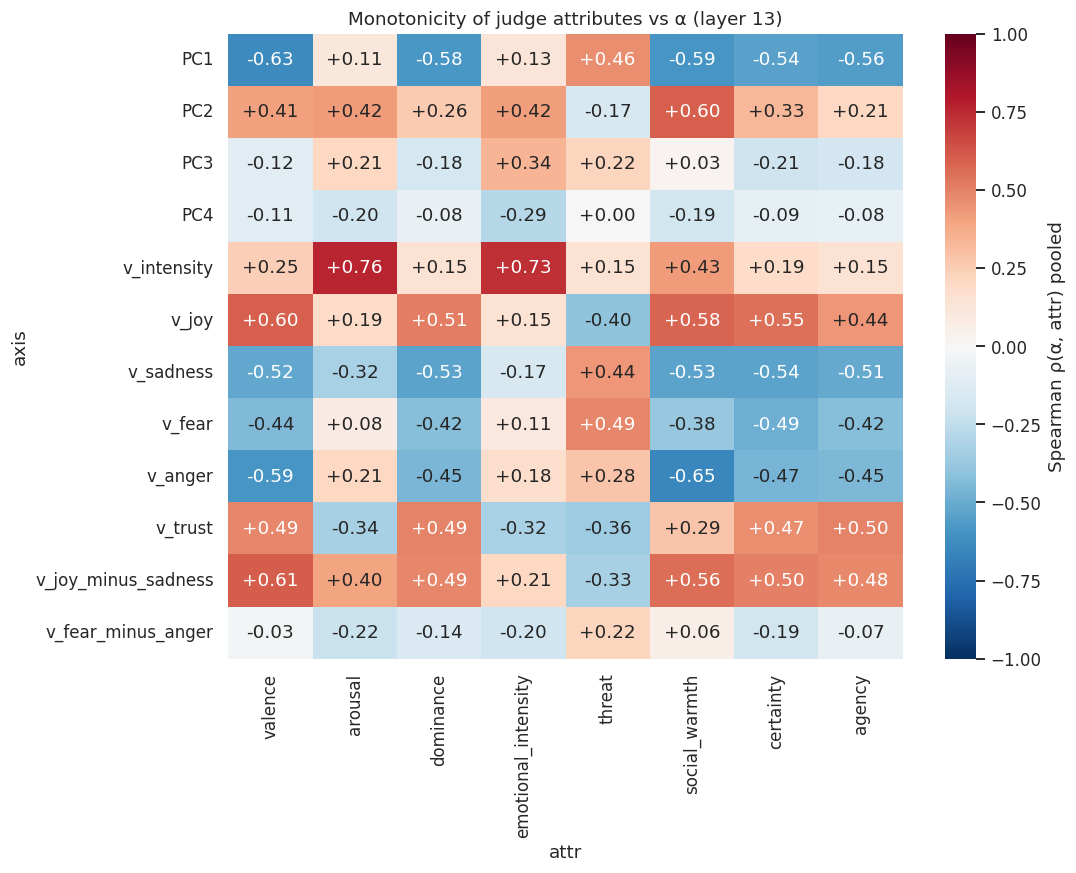

attr,valence,arousal,dominance,emotional_intensity,threat,social_warmth,certainty,agency
axis,,,,,,,,
PC1,-0.63,0.11,-0.58,0.13,0.46,-0.59,-0.54,-0.56
PC2,0.41,0.42,0.26,0.42,-0.17,0.60,0.33,0.21
PC3,-0.12,0.21,-0.18,0.34,0.22,0.03,-0.21,-0.18
PC4,-0.11,-0.20,-0.08,-0.29,0.00,-0.19,-0.09,-0.08
v_intensity,0.25,0.76,0.15,0.73,0.15,0.43,0.19,0.15
v_joy,0.60,0.19,0.51,0.15,-0.40,0.58,0.55,0.44
v_sadness,-0.52,-0.32,-0.53,-0.17,0.44,-0.53,-0.54,-0.51
v_fear,-0.44,0.08,-0.42,0.11,0.49,-0.38,-0.49,-0.42
v_anger,-0.59,0.21,-0.45,0.18,0.28,-0.65,-0.47,-0.45


In [32]:
def slope_rho(df: pd.DataFrame, axis: str, attr: str) -> tuple[float, float]:
    """Return (Spearman rho over (alpha, attr) pooled across prompts, mean per-prompt rho)."""
    sub = df[df['axis'] == axis]
    if len(sub) < 3 or sub['alpha'].nunique() < 3 or sub[attr].std() < 1e-9:
        return float('nan'), float('nan')
    pooled = stats.spearmanr(sub['alpha'], sub[attr]).statistic
    per_prompt = []
    for _, g in sub.groupby('prompt'):
        if g['alpha'].nunique() < 3 or g[attr].std() < 1e-9:
            continue
        per_prompt.append(stats.spearmanr(g['alpha'], g[attr]).statistic)
    return float(pooled), float(np.mean(per_prompt)) if per_prompt else float('nan')

sweep_judged = JUDGE_DF[JUDGE_DF['axis'].isin(SWEEP_AXES)].copy()

rho_rows = []
for axis in SWEEP_AXES:
    for attr in JUDGE_ATTRS:
        pooled, per_prompt = slope_rho(sweep_judged, axis, attr)
        rho_rows.append({'axis': axis, 'attr': attr,
                         'rho_pooled': pooled, 'rho_per_prompt_mean': per_prompt})
RHO = pd.DataFrame(rho_rows)
RHO.to_csv(OUT_DIR / 'axis_attr_monotonicity.csv', index=False)

RHO_MAT = RHO.pivot(index='axis', columns='attr', values='rho_pooled').reindex(SWEEP_AXES)[JUDGE_ATTRS]
fig, ax = plt.subplots(figsize=(10, 0.55 * len(SWEEP_AXES) + 1.5))
sns.heatmap(RHO_MAT.astype(float), annot=True, fmt='+.2f', center=0, vmin=-1, vmax=1,
            cmap='RdBu_r', ax=ax, cbar_kws={'label': 'Spearman ρ(α, attr) pooled'})
ax.set_title(f'Monotonicity of judge attributes vs α (layer {STEER_LAYER})')
fig.tight_layout()
fig.savefig(OUT_DIR / 'monotonicity_heatmap.png', dpi=140)
plt.show()
RHO_MAT.round(2)

In [33]:
# Check predicted-direction agreement: |rho| where prediction is nonzero, and the
# fraction of nonzero predictions that actually got the sign right.
agree_rows = []
for axis, preds in PREDICTED_SIGN.items():
    if axis not in RHO_MAT.index:
        continue
    for attr, pred in preds.items():
        if pred == 0:
            continue
        rho = RHO_MAT.loc[axis, attr]
        if pd.isna(rho):
            continue
        agree_rows.append({
            'axis': axis, 'attr': attr,
            'predicted_sign': pred, 'rho': float(rho),
            'sign_match': int(np.sign(rho) == pred),
            'abs_rho': float(abs(rho)),
        })
AGREE = pd.DataFrame(agree_rows)
AGREE.to_csv(OUT_DIR / 'prediction_agreement.csv', index=False)
if len(AGREE):
    summary = AGREE.groupby('axis').agg(
        sign_match_rate=('sign_match', 'mean'),
        mean_abs_rho=('abs_rho', 'mean'),
        n_predicted=('attr', 'count'),
    ).round(3)
    print(summary)
    summary.to_csv(OUT_DIR / 'prediction_agreement_summary.csv')

             sign_match_rate  mean_abs_rho  n_predicted
axis                                                   
PC1                     1.00         0.450            8
PC2                     1.00         0.353            8
PC3                     0.75         0.185            8
PC4                     1.00         0.130            8
v_intensity             1.00         0.746            2


## 10. α-curves per (axis, attribute)

Line plot: x = α, y = mean judge score over prompts ± SD. One panel per axis,
all 8 attributes overlaid.

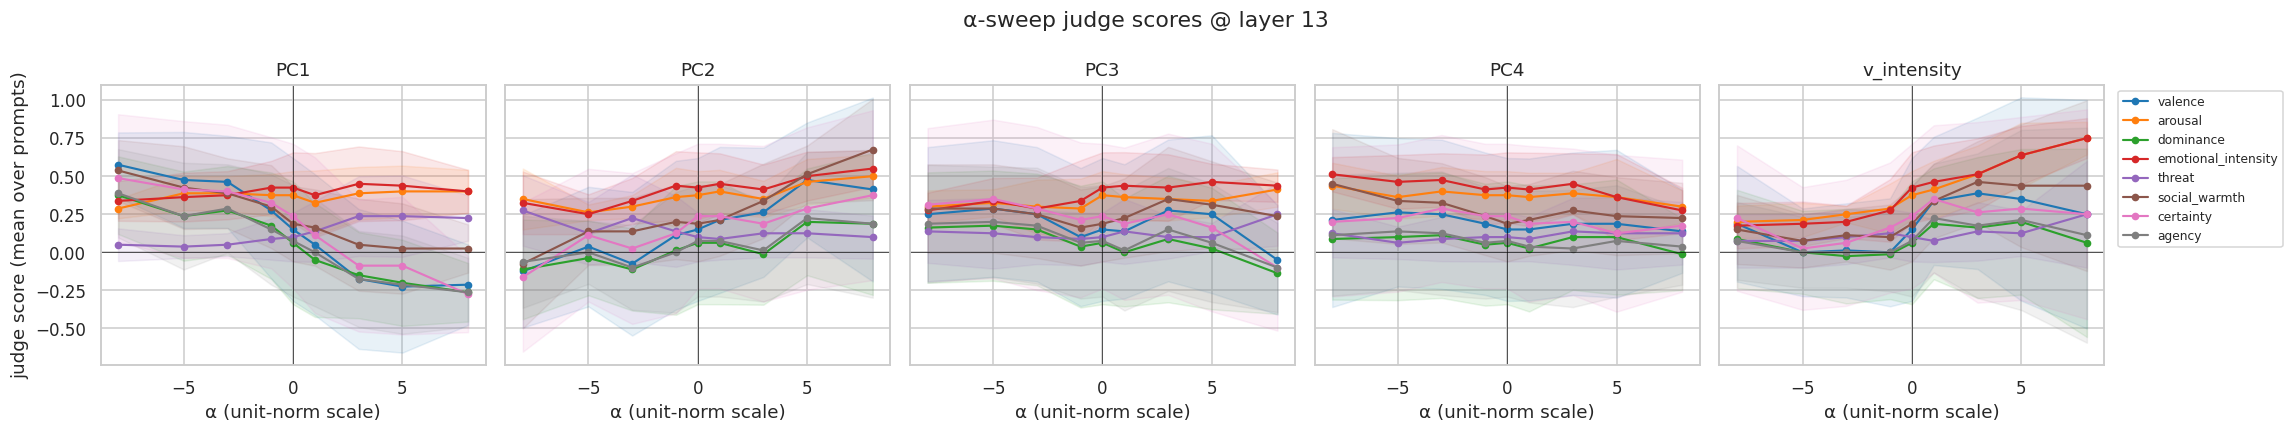

In [34]:
def alpha_curves(axis: str, df: pd.DataFrame) -> pd.DataFrame:
    sub = df[df['axis'] == axis].copy()
    if len(sub) == 0:
        return pd.DataFrame()
    mean = sub.groupby('alpha')[JUDGE_ATTRS].mean().add_suffix('_mean')
    std  = sub.groupby('alpha')[JUDGE_ATTRS].std().add_suffix('_std')
    out  = pd.concat([mean, std], axis=1).reset_index()
    return out

axes_to_plot = [a for a in ['PC1', 'PC2', 'PC3', 'PC4', 'v_intensity'] if a in SWEEP_AXES]
n = len(axes_to_plot)
fig, axarr = plt.subplots(1, n, figsize=(4.2 * n, 4.0), sharey=True)
if n == 1: axarr = [axarr]
palette = sns.color_palette('tab10', n_colors=len(JUDGE_ATTRS))
for ax, axis_name in zip(axarr, axes_to_plot):
    curves = alpha_curves(axis_name, sweep_judged)
    alpha_vals = curves['alpha'].to_numpy()
    for i, attr in enumerate(JUDGE_ATTRS):
        m = curves[f'{attr}_mean'].to_numpy()
        s = curves[f'{attr}_std'].to_numpy()
        ax.plot(alpha_vals, m, '-o', color=palette[i], label=attr, lw=1.4, ms=4)
        ax.fill_between(alpha_vals, m - s, m + s, color=palette[i], alpha=0.10)
    ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)
    ax.set_title(axis_name); ax.set_xlabel('α (unit-norm scale)')
axarr[0].set_ylabel('judge score (mean over prompts)')
axarr[-1].legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
fig.suptitle(f'α-sweep judge scores @ layer {STEER_LAYER}')
fig.tight_layout()
fig.savefig(OUT_DIR / 'alpha_curves_axes.png', dpi=140)
plt.show()

## 11. PC vs named-emotion steering

For each axis, define **controllability** as the mean of `|rho_pooled|` across the
*predicted-relevant* attributes (those with nonzero `PREDICTED_SIGN`). Higher = the
axis moves what we expected it to move; lower = the axis is more diffuse.

For named-emotion vectors we *don't* have an a-priori per-attribute prediction
(other than from the existing literature). As a fair comparison we use the
**max** |rho| over attributes as that vector's strongest controllable attribute,
and report the attribute name.

In [35]:
ctrl_rows = []
for axis in SWEEP_AXES:
    row = RHO_MAT.loc[axis].astype(float)
    abs_row = row.abs()
    if abs_row.dropna().empty:
        continue
    top_attr = abs_row.idxmax()
    top_rho  = float(row[top_attr])
    # Predicted-relevant: only for axes that have a prediction.
    pred = PREDICTED_SIGN.get(axis, {})
    relevant = [a for a, s in pred.items() if s != 0]
    rho_on_pred = float(abs_row.reindex(relevant).mean()) if relevant else float('nan')
    ctrl_rows.append({
        'axis': axis,
        'top_attr': top_attr,
        'top_rho': top_rho,
        'mean_abs_rho_on_predicted_attrs': rho_on_pred,
        'mean_abs_rho_all_attrs': float(abs_row.mean()),
    })
CTRL = pd.DataFrame(ctrl_rows)
if 'top_rho' in CTRL.columns and len(CTRL):
    CTRL = CTRL.sort_values('top_rho', key=lambda c: c.abs(), ascending=False)
CTRL.to_csv(OUT_DIR / 'controllability_by_axis.csv', index=False)
CTRL.round(3)

,axis,top_attr,top_rho,mean_abs_rho_on_predicted_attrs,mean_abs_rho_all_attrs
4,v_intensity,arousal,0.762,0.746,0.351
8,v_anger,social_warmth,-0.650,NaN,0.409
0,PC1,valence,-0.633,0.450,0.450
10,v_joy_minus_sadness,valence,0.609,NaN,0.447
1,PC2,social_warmth,0.600,0.353,0.353
5,v_joy,valence,0.598,NaN,0.429
6,v_sadness,certainty,-0.535,NaN,0.445
9,v_trust,agency,0.498,NaN,0.407
7,v_fear,certainty,-0.492,NaN,0.354
2,PC3,emotional_intensity,0.342,0.185,0.185


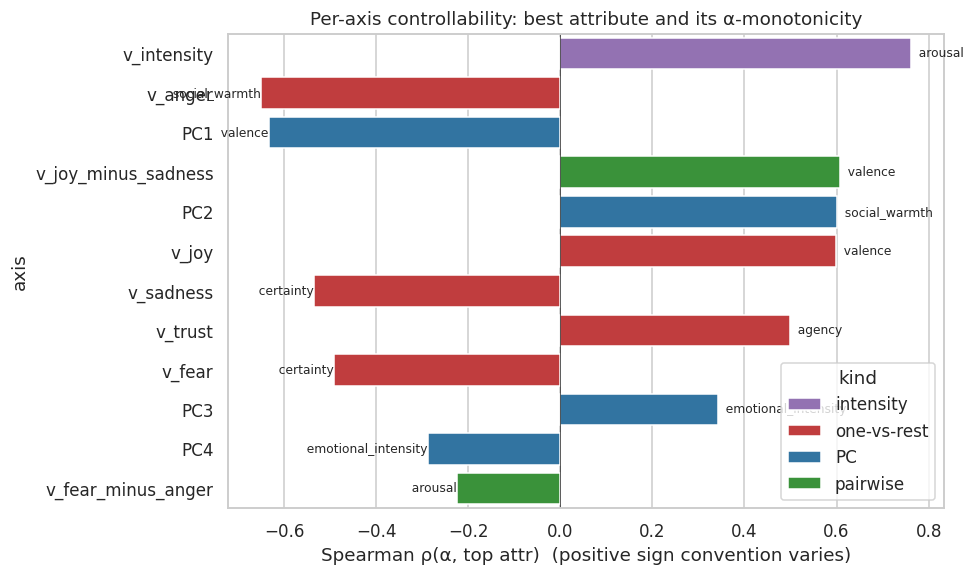

In [36]:
# Visual: top-attr |rho| bar chart, color-coded by axis type.
if len(CTRL) == 0:
    print('CTRL is empty (judge probably had constant scores). Skipping plot.')
else:
  kind = []
  for a in CTRL['axis']:
      if a.startswith('PC'):                 kind.append('PC')
      elif a == 'v_intensity':               kind.append('intensity')
      elif '_minus_' in a:                   kind.append('pairwise')
      else:                                  kind.append('one-vs-rest')
  CTRL_PLOT = CTRL.assign(kind=kind).copy()
  fig, ax = plt.subplots(figsize=(9, 0.35 * len(CTRL_PLOT) + 1.2))
  sns.barplot(data=CTRL_PLOT, y='axis', x='top_rho', hue='kind', dodge=False, ax=ax,
              palette={'PC': '#1f77b4', 'intensity': '#9467bd',
                       'pairwise': '#2ca02c', 'one-vs-rest': '#d62728'})
  ax.axvline(0, color='k', lw=0.4)
  ax.set_xlabel('Spearman ρ(α, top attr)  (positive sign convention varies)')
  ax.set_title('Per-axis controllability: best attribute and its α-monotonicity')
  for i, (_, r) in enumerate(CTRL_PLOT.iterrows()):
      ax.text(r['top_rho'], i, f"  {r['top_attr']}", va='center',
              ha='left' if r['top_rho'] >= 0 else 'right', fontsize=8)
  fig.tight_layout()
  fig.savefig(OUT_DIR / 'controllability_bar.png', dpi=140)
  plt.show()

## 12. Representative generations along each PC axis

Pick one prompt and show the full α-sweep so the change is readable.

In [37]:
DEMO_PROMPT = PROMPTS[0]
demo = sweep_judged[sweep_judged['prompt'] == DEMO_PROMPT].copy()
for axis_name in [a for a in ['PC1', 'PC2', 'PC3', 'PC4', 'v_intensity'] if a in SWEEP_AXES]:
    sub = demo[demo['axis'] == axis_name].sort_values('alpha')
    print(f"\n{'='*70}")
    print(f"PROMPT : {DEMO_PROMPT}")
    print(f"AXIS   : {axis_name}")
    print('='*70)
    for _, r in sub.iterrows():
        v = r.get('valence', float('nan'))
        w = r.get('social_warmth', float('nan'))
        t = r.get('threat', float('nan'))
        a = r.get('arousal', float('nan'))
        short = r['output'][:200].replace('\n', ' ')
        print(f"  α={r['alpha']:+.1f}  v={v:+.2f} w={w:+.2f} t={t:+.2f} a={a:+.2f}  {short}")


PROMPT : I guess that was okay.
AXIS   : PC1
  α=-8.0  v=+0.50 w=+0.50 t=+0.00 a=+0.20  The event was satisfactory.
  α=-5.0  v=+0.20 w=+0.10 t=+0.00 a=+0.30  It was a decent experience.
  α=-3.0  v=+0.20 w=+0.10 t=+0.00 a=+0.30  It was a decent experience.
  α=-1.0  v=+0.20 w=+0.10 t=+0.00 a=+0.30  It was a decent experience.
  α=+0.0  v=+0.20 w=+0.10 t=+0.00 a=+0.30  It was a decent experience.
  α=+1.0  v=+0.00 w=+0.00 t=+0.00 a=+0.00  It was an average experience.
  α=+3.0  v=+0.20 w=+0.10 t=+0.10 a=+0.30  I suppose that was somewhat satisfactory.
  α=+5.0  v=-0.20 w=+0.00 t=+0.00 a=+0.30  I was expecting a more enthusiastic response, but I guess that was just "meh" - it was just okay.
  α=+8.0  v=+0.10 w=+0.00 t=+0.00 a=+0.30  I was expecting a more disappointing experience, but it was just a mediocre experience, but I guess it was just okay.

PROMPT : I guess that was okay.
AXIS   : PC2
  α=-8.0  v=-0.20 w=+0.00 t=+0.20 a=+0.30  You're not sure if you're satisfied with the situa

## 13. Summary

In [38]:
summary = {
    'steer_layer': STEER_LAYER,
    'alpha_grid': ALPHA_GRID,
    'n_prompts': len(PROMPTS),
    'sweep_axes': SWEEP_AXES,
    'judge_model': JUDGE_MODEL,
    'dry_run_gen': DRY_RUN_GEN,
    'dry_run_judge': DRY_RUN_JUDGE,
    'rho_pooled': RHO_MAT.astype(float).round(4).to_dict(orient='index'),
    'predicted_sign': PREDICTED_SIGN,
    'prediction_agreement': AGREE.to_dict(orient='records') if len(AGREE) else [],
    'controllability_by_axis': CTRL.round(4).to_dict(orient='records'),
    'pc_singular_values': [float(s) for s in S[:K_PCS]],
    'pc_evr': [float(e) for e in evr[:K_PCS]],
}
with open(OUT_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('wrote', OUT_DIR / 'summary.json')

wrote /home/maplesugano/proj/EmotionEngine_v2/analysis/emotion_intensity/subspace_steering/summary.json
